# Inflation-Adjusted Performance of Indian Equities and Gold

### Objective
The objective of this project is to compare the nominal and real (inflation-adjusted) performance of Indian equities (NIFTY 50) and gold, and to evaluate their effectiveness in preserving purchasing power across different inflation regimes.


## 1. Problem Statement

Inflation erodes purchasing power over time, making nominal investment returns an incomplete measure of wealth creation. This project examines whether Indian equities and gold are effective in preserving real purchasing power, particularly under varying inflation environments.


## 2. Data Sources

- **NIFTY 50 Index**: Daily closing prices sourced from Yahoo Finance  
- **Gold Prices**: Yearly gold prices used as a proxy for gold returns  
- **Inflation**: Annual CPI inflation data for India sourced from the World Bank


## 3. Methodology

- Daily asset prices were cleaned and sorted chronologically  
- Year-end prices were used to compute annual returns  
- Nominal returns were adjusted for inflation to obtain real returns  
- Inflation regimes were classified as low (<4%), moderate (4–6%), and high (>6%)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 


In [3]:
gold      = pd.read_csv('./data/gold_monthly_international.csv')
nifty     = pd.read_csv('./data/nifty_daily.csv')
inflation = pd.read_csv('./data/inflation_india.csv')


In [4]:
gold.head()

,Date,Price
0,12/1/2025,"$4,322.36"
1,11/1/2025,"$4,217.36"
2,10/1/2025,"$4,002.77"
3,9/1/2025,"$3,836.23"
4,8/1/2025,"$3,415.77"


In [5]:
gold['Price'] = (
    gold['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

gold['Price'] = gold['Price'].astype(float).astype(int)


In [6]:
gold.head()

,Date,Price
0,12/1/2025,4322
1,11/1/2025,4217
2,10/1/2025,4002
3,9/1/2025,3836
4,8/1/2025,3415


In [7]:
nifty.head()

,Date,Close,High,Low,Open,Volume
0,1/4/2010,5232.200195,5238.450195,5167.100098,5200.899902,0
1,1/5/2010,5277.899902,5288.350098,5242.399902,5277.149902,0
2,1/6/2010,5281.799805,5310.850098,5260.049805,5278.149902,0
3,1/7/2010,5263.100098,5302.549805,5244.750000,5281.799805,0
4,1/8/2010,5244.750000,5276.750000,5234.700195,5264.250000,0


In [8]:
inflation.head()

,Year,Inflation
0,2025,2.20
1,2024,4.95
2,2023,5.65
3,2022,6.70
4,2021,5.13


## 4. Data Preparation

Daily price data was cleaned by removing irrelevant columns, converting dates to datetime format, and sorting chronologically. Inflation data was prepared at an annual frequency to ensure consistency across datasets.


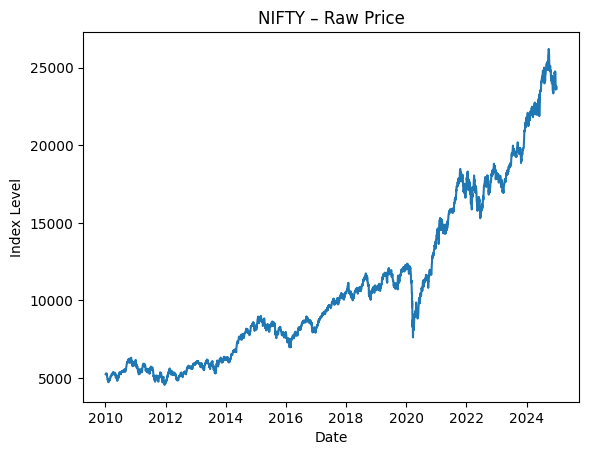

In [9]:
nifty['Date'] = pd.to_datetime(nifty['Date'])
nifty = nifty.sort_values('Date')

plt.figure()
plt.plot(nifty['Date'], nifty['Close'])
plt.title("NIFTY – Raw Price")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.show()



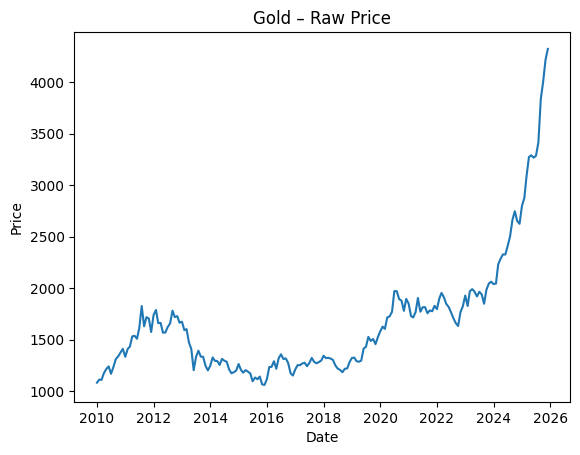

In [10]:


# ---- GOLD ----
gold['Date'] = pd.to_datetime(gold['Date'])
gold = gold.sort_values('Date')

plt.figure()
plt.plot(gold['Date'], gold['Price'])
plt.title("Gold – Raw Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()



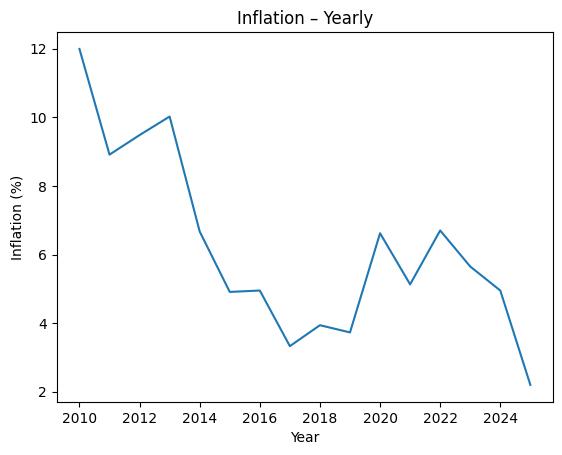

In [11]:
plt.figure()
plt.plot(inflation['Year'], inflation['Inflation'])
plt.title("Inflation – Yearly")
plt.xlabel("Year")
plt.ylabel("Inflation (%)")
plt.show()

In [12]:
# Sort NIFTY and Gold by Date
nifty = nifty.sort_values("Date").reset_index(drop=True)
gold = gold.sort_values("Date").reset_index(drop=True)


In [13]:
# Sort Inflation by Year
inflation = inflation.sort_values("Year").reset_index(drop=True)


In [14]:
nifty = nifty[["Date", "Close"]]
nifty["Close"] = nifty["Close"].round().astype(int)

In [15]:
nifty.head()

,Date,Close
0,2010-01-04,5232
1,2010-01-05,5278
2,2010-01-06,5282
3,2010-01-07,5263
4,2010-01-08,5245


In [16]:
nifty["Year"] = nifty["Date"].dt.year


In [17]:
nifty = nifty.sort_values("Date").reset_index(drop=True)


In [18]:
nifty_year_end = (
    nifty
    .groupby("Year", as_index=False)
    .last()
)


In [19]:
nifty_year_end.head()


,Year,Date,Close
0,2010,2010-12-31,6134
1,2011,2011-12-30,4624
2,2012,2012-12-31,5905
3,2013,2013-12-31,6304
4,2014,2014-12-31,8283


In [20]:
nifty_year_end = nifty_year_end[["Year", "Close"]]


In [21]:
nifty_year_end["NIFTY_Annual_Return"] = (
    nifty_year_end["Close"].pct_change() * 100
)
nifty_year_end = nifty_year_end.dropna().reset_index(drop=True)



In [22]:
nifty_annual_price=nifty_year_end

In [23]:
nifty_annual_price.head()

,Year,Close,NIFTY_Annual_Return
0,2011,4624,-24.616889
1,2012,5905,27.703287
2,2013,6304,6.756986
3,2014,8283,31.392766
4,2015,7946,-4.068574


In [24]:
gold["Year"] = gold["Date"].dt.year


In [25]:
gold_annual_price = (
    gold
    .groupby("Year")["Price"]
    .last()
    .reset_index()
)


In [26]:
gold_annual_price["Gold_Annual_Return"] = (
    gold_annual_price["Price"].pct_change() * 100
)


In [27]:
gold_annual_price = gold_annual_price.dropna().reset_index(drop=True)


In [28]:
gold_annual_price.head()


,Year,Price,Gold_Annual_Return
0,2011,1574,11.631206
1,2012,1664,5.717916
2,2013,1201,-27.824519
3,2014,1199,-0.166528
4,2015,1060,-11.592994


## 5. Nominal Return Analysis



In [29]:
master_df = (
    nifty_annual_price[["Year", "NIFTY_Annual_Return"]]
    .merge(
        gold_annual_price[["Year", "Gold_Annual_Return"]],
        on="Year",
        how="inner"
    )
    .merge(
        inflation[["Year", "Inflation"]],
        on="Year",
        how="inner"
    )
)


In [30]:
master_df["Real_NIFTY_Return"] = (
    master_df["NIFTY_Annual_Return"] - master_df["Inflation"]
)

master_df["Real_Gold_Return"] = (
    master_df["Gold_Annual_Return"] - master_df["Inflation"]
)


In [31]:
master_df.head()

,Year,NIFTY_Annual_Return,Gold_Annual_Return,Inflation,Real_NIFTY_Return,Real_Gold_Return
0,2011,-24.616889,11.631206,8.91,-33.526889,2.721206
1,2012,27.703287,5.717916,9.48,18.223287,-3.762084
2,2013,6.756986,-27.824519,10.02,-3.263014,-37.844519
3,2014,31.392766,-0.166528,6.67,24.722766,-6.836528
4,2015,-4.068574,-11.592994,4.91,-8.978574,-16.502994


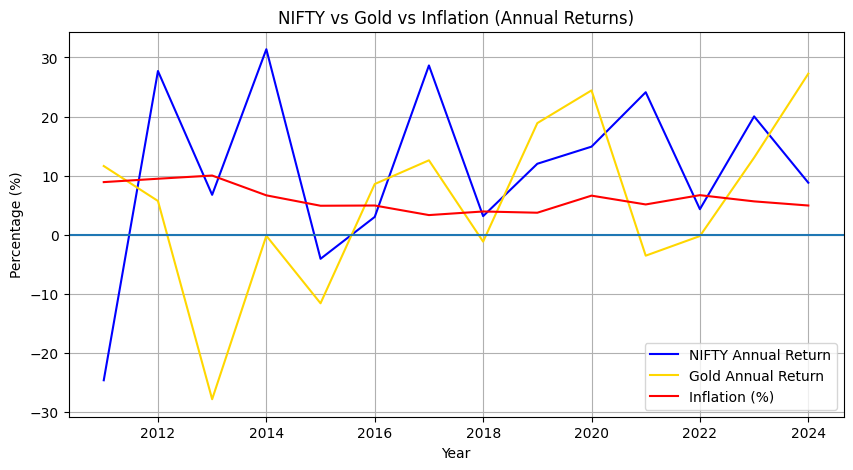

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(master_df["Year"], master_df["NIFTY_Annual_Return"], label="NIFTY Annual Return", color="blue")
plt.plot(master_df["Year"], master_df["Gold_Annual_Return"], label="Gold Annual Return", color="gold")
plt.plot(master_df["Year"], master_df["Inflation"], label="Inflation (%)", color="red")

plt.axhline(0)
plt.xlabel("Year")
plt.ylabel("Percentage (%)")
plt.title("NIFTY vs Gold vs Inflation (Annual Returns)")
plt.legend()
plt.grid(True)

plt.show()


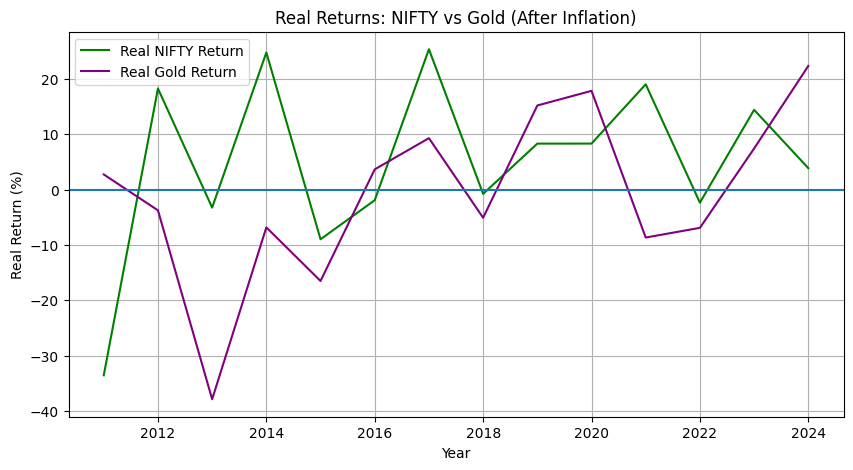

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(master_df["Year"], master_df["Real_NIFTY_Return"], label="Real NIFTY Return", color="green")
plt.plot(master_df["Year"], master_df["Real_Gold_Return"], label="Real Gold Return", color="purple")

plt.axhline(0)
plt.xlabel("Year")
plt.ylabel("Real Return (%)")
plt.title("Real Returns: NIFTY vs Gold (After Inflation)")
plt.legend()
plt.grid(True)

plt.show()


In [34]:
heatmap_df = master_df[[
    "Year",
    "Real_NIFTY_Return",
    "Real_Gold_Return"
]].set_index("Year").T

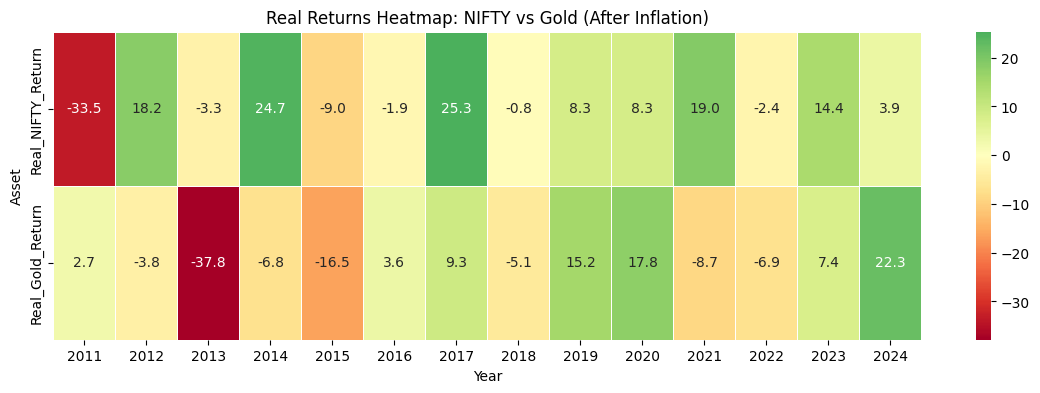

In [35]:
plt.figure(figsize=(14, 4))

sns.heatmap(
    heatmap_df,
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    annot=True,
    fmt=".1f"
)

plt.title("Real Returns Heatmap: NIFTY vs Gold (After Inflation)")
plt.xlabel("Year")
plt.ylabel("Asset")

plt.show()


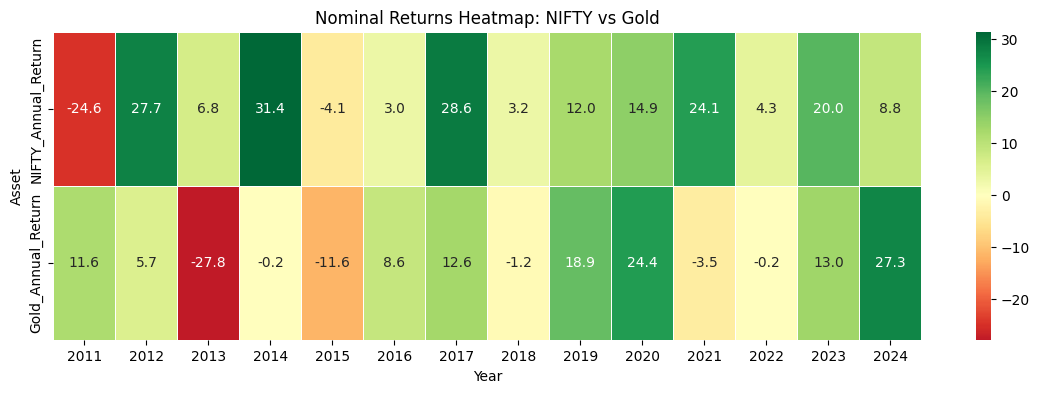

In [36]:
nominal_heatmap_df = master_df[[
    "Year",
    "NIFTY_Annual_Return",
    "Gold_Annual_Return"
]].set_index("Year").T

plt.figure(figsize=(14, 4))
sns.heatmap(
    nominal_heatmap_df,
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    annot=True,
    fmt=".1f"
)

plt.title("Nominal Returns Heatmap: NIFTY vs Gold")
plt.xlabel("Year")
plt.ylabel("Asset")

plt.show()


In [37]:
master_df.head()

,Year,NIFTY_Annual_Return,Gold_Annual_Return,Inflation,Real_NIFTY_Return,Real_Gold_Return
0,2011,-24.616889,11.631206,8.91,-33.526889,2.721206
1,2012,27.703287,5.717916,9.48,18.223287,-3.762084
2,2013,6.756986,-27.824519,10.02,-3.263014,-37.844519
3,2014,31.392766,-0.166528,6.67,24.722766,-6.836528
4,2015,-4.068574,-11.592994,4.91,-8.978574,-16.502994


Mean & Median

In [38]:
stats_summary = {
    "Asset": ["NIFTY", "Gold"],
    "Mean Real Return (%)": [
        master_df["Real_NIFTY_Return"].mean(),
        master_df["Real_Gold_Return"].mean()
    ],
    "Median Real Return (%)": [
        master_df["Real_NIFTY_Return"].median(),
        master_df["Real_Gold_Return"].median()
    ]
}

stats_df = pd.DataFrame(stats_summary)
stats_df


,Asset,Mean Real Return (%),Median Real Return (%)
0,NIFTY,5.085558,6.070475
1,Gold,-0.523844,-0.520439


Volatility

In [39]:
stats_df["Volatility (Std Dev %)"] = [
    master_df["Real_NIFTY_Return"].std(),
    master_df["Real_Gold_Return"].std()
]

stats_df


,Asset,Mean Real Return (%),Median Real Return (%),Volatility (Std Dev %)
0,NIFTY,5.085558,6.070475,15.607761
1,Gold,-0.523844,-0.520439,15.482541


Best & Worst Years

In [40]:
stats_df["Best Year (%)"] = [
    master_df["Real_NIFTY_Return"].max(),
    master_df["Real_Gold_Return"].max()
]

stats_df["Worst Year (%)"] = [
    master_df["Real_NIFTY_Return"].min(),
    master_df["Real_Gold_Return"].min()
]

stats_df


,Asset,Mean Real Return (%),Median Real Return (%),Volatility (Std Dev %),Best Year (%),Worst Year (%)
0,NIFTY,5.085558,6.070475,15.607761,25.316470,-33.526889
1,Gold,-0.523844,-0.520439,15.482541,22.305092,-37.844519


% of Years with Negative Real Returns

In [41]:
stats_df["% Years Negative Real Return"] = [
    (master_df["Real_NIFTY_Return"] < 0).mean() * 100,
    (master_df["Real_Gold_Return"] < 0).mean() * 100
]

stats_df


,Asset,Mean Real Return (%),Median Real Return (%),Volatility (Std Dev %),Best Year (%),Worst Year (%),% Years Negative Real Return
0,NIFTY,5.085558,6.070475,15.607761,25.316470,-33.526889,42.857143
1,Gold,-0.523844,-0.520439,15.482541,22.305092,-37.844519,50.000000


In [42]:
sharpe_nifty = master_df['Real_NIFTY_Return'].mean() / master_df['Real_NIFTY_Return'].std()
sharpe_gold  = master_df['Real_Gold_Return'].mean()  / master_df['Real_Gold_Return'].std()

stats_df["Sharpe Ratio"] = [round(sharpe_nifty, 3), round(sharpe_gold, 3)]
stats_df

,Asset,Mean Real Return (%),Median Real Return (%),Volatility (Std Dev %),Best Year (%),Worst Year (%),% Years Negative Real Return,Sharpe Ratio
0,NIFTY,5.085558,6.070475,15.607761,25.316470,-33.526889,42.857143,0.326
1,Gold,-0.523844,-0.520439,15.482541,22.305092,-37.844519,50.000000,-0.034


Inflation Regime Classification

In [43]:
def inflation_regime(infl):
    if infl < 4:
        return "Low Inflation"
    elif infl <= 6:
        return "Moderate Inflation"
    else:
        return "High Inflation"

master_df["Inflation_Regime"] = master_df["Inflation"].apply(inflation_regime)


In [44]:
master_df[["Year", "Inflation", "Inflation_Regime"]]


,Year,Inflation,Inflation_Regime
0,2011,8.91,High Inflation
1,2012,9.48,High Inflation
2,2013,10.02,High Inflation
3,2014,6.67,High Inflation
4,2015,4.91,Moderate Inflation
5,2016,4.95,Moderate Inflation
6,2017,3.33,Low Inflation
7,2018,3.94,Low Inflation
8,2019,3.73,Low Inflation
9,2020,6.62,High Inflation


Average Real Returns by Inflation Regime

In [45]:
regime_analysis = (
    master_df
    .groupby("Inflation_Regime")[["Real_NIFTY_Return", "Real_Gold_Return"]]
    .mean()
    .reset_index()
)

regime_analysis


,Inflation_Regime,Real_NIFTY_Return,Real_Gold_Return
0,High Inflation,2.011940,-5.805878
1,Low Inflation,10.937441,6.443942
2,Moderate Inflation,5.262769,1.633926


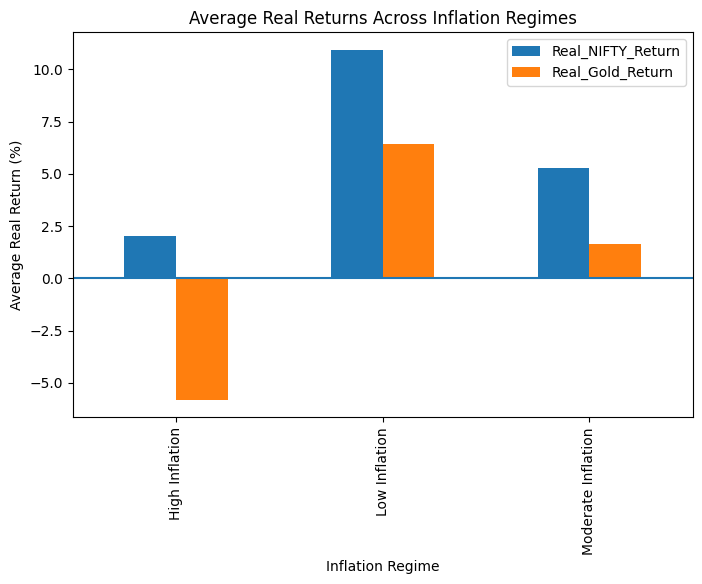

In [46]:
regime_analysis.set_index("Inflation_Regime").plot(
    kind="bar",
    figsize=(8,5)
)

plt.axhline(0)
plt.title("Average Real Returns Across Inflation Regimes")
plt.ylabel("Average Real Return (%)")
plt.xlabel("Inflation Regime")
plt.legend()
plt.show()

## 6. Long-Term Price Growth: NIFTY vs Gold

To compare long-term wealth creation, asset prices are indexed to a common base value of 100. This allows a direct comparison of relative growth over time.


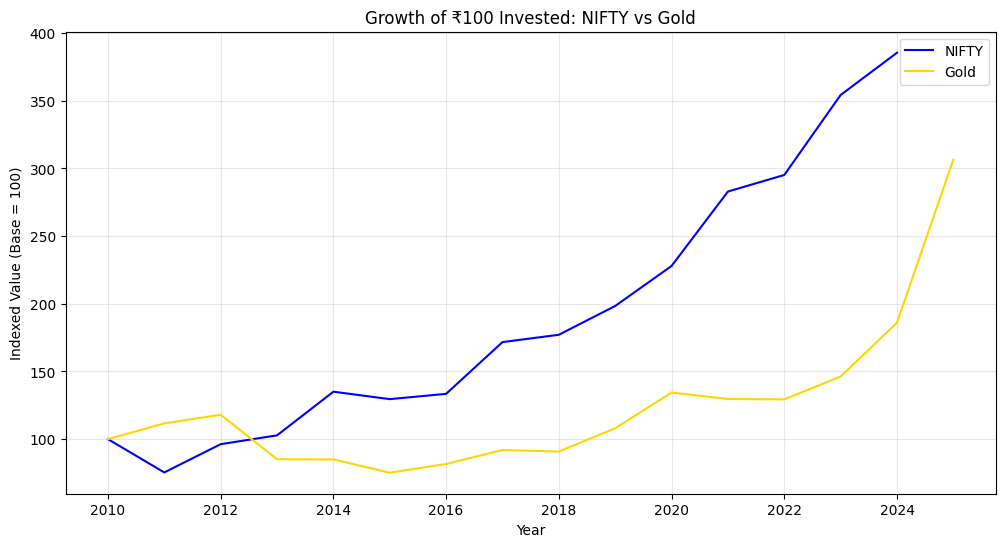

In [47]:
# Create indexed price series (base = 100)
nifty_indexed = (
    nifty.groupby("Year")["Close"].last() / nifty.groupby("Year")["Close"].last().iloc[0]
) * 100

gold_indexed = (
    gold.groupby("Year")["Price"].last() / gold.groupby("Year")["Price"].last().iloc[0]
) * 100

plt.figure(figsize=(12, 6))
plt.plot(nifty_indexed.index, nifty_indexed.values, label="NIFTY", color="blue")
plt.plot(gold_indexed.index, gold_indexed.values, label="Gold", color="gold")

plt.title("Growth of ₹100 Invested: NIFTY vs Gold")
plt.xlabel("Year")
plt.ylabel("Indexed Value (Base = 100)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [48]:
#Annual Returns Comparison (Bar Chart)

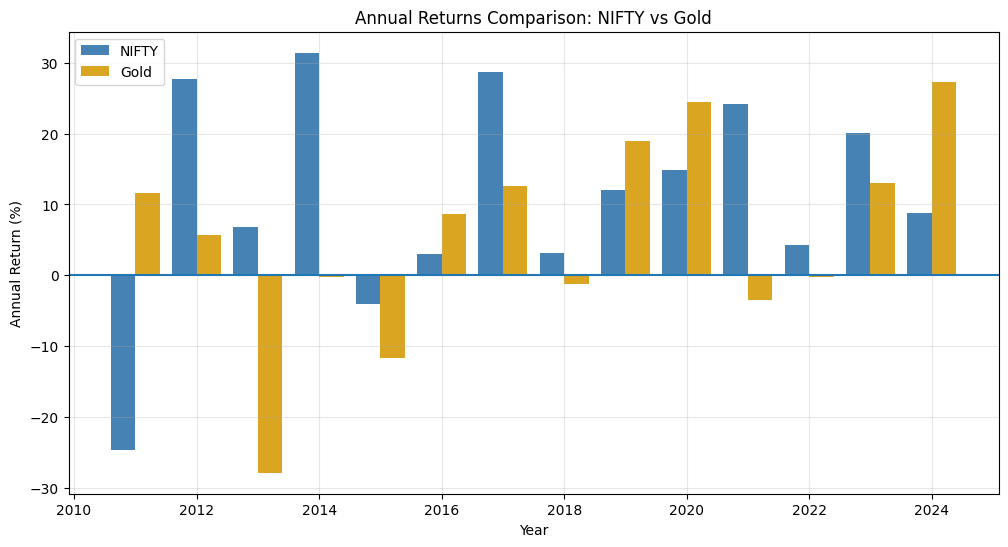

In [49]:
plt.figure(figsize=(12, 6))

plt.bar(master_df["Year"] - 0.2, master_df["NIFTY_Annual_Return"],
        width=0.4, label="NIFTY", color="steelblue")

plt.bar(master_df["Year"] + 0.2, master_df["Gold_Annual_Return"],
        width=0.4, label="Gold", color="goldenrod")

plt.axhline(0)
plt.title("Annual Returns Comparison: NIFTY vs Gold")
plt.xlabel("Year")
plt.ylabel("Annual Return (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Inflation vs Asset Returns

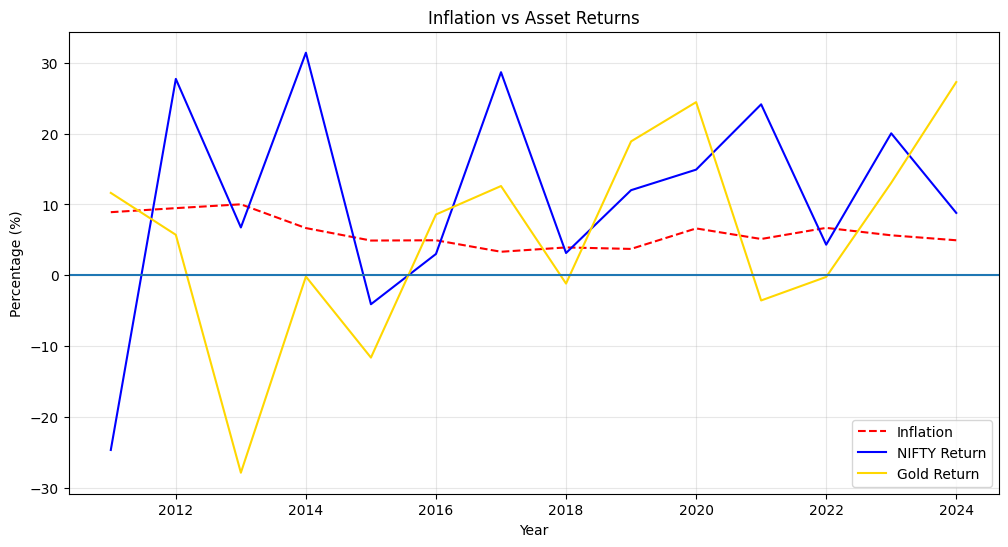

In [50]:
plt.figure(figsize=(12, 6))

plt.plot(master_df["Year"], master_df["Inflation"],
         label="Inflation", color="red", linestyle="--")

plt.plot(master_df["Year"], master_df["NIFTY_Annual_Return"],
         label="NIFTY Return", color="blue")

plt.plot(master_df["Year"], master_df["Gold_Annual_Return"],
         label="Gold Return", color="gold")

plt.axhline(0)
plt.title("Inflation vs Asset Returns")
plt.xlabel("Year")
plt.ylabel("Percentage (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Real Returns Comparison

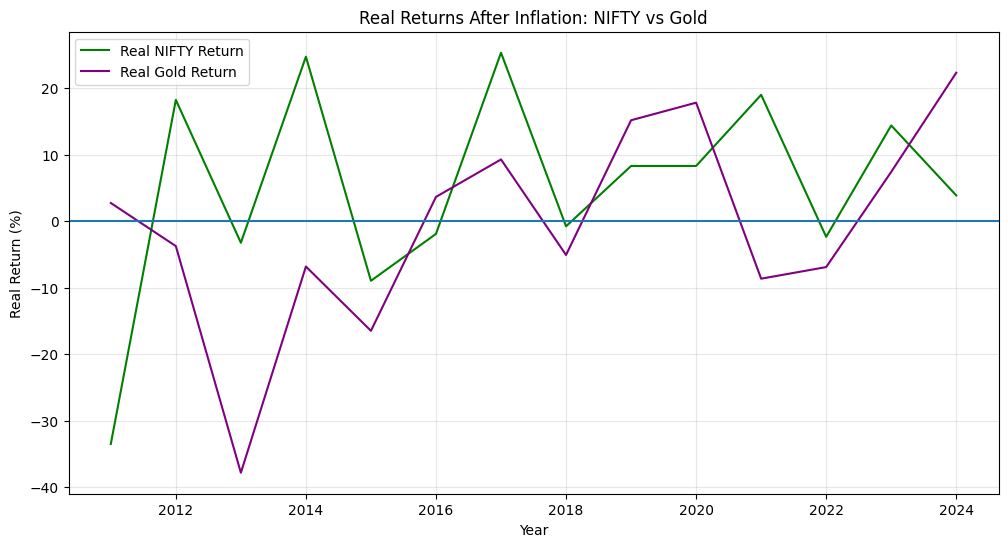

In [51]:
plt.figure(figsize=(12, 6))

plt.plot(master_df["Year"], master_df["Real_NIFTY_Return"],
         label="Real NIFTY Return", color="green")

plt.plot(master_df["Year"], master_df["Real_Gold_Return"],
         label="Real Gold Return", color="purple")

plt.axhline(0)
plt.title("Real Returns After Inflation: NIFTY vs Gold")
plt.xlabel("Year")
plt.ylabel("Real Return (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Rolling Average Real Returns

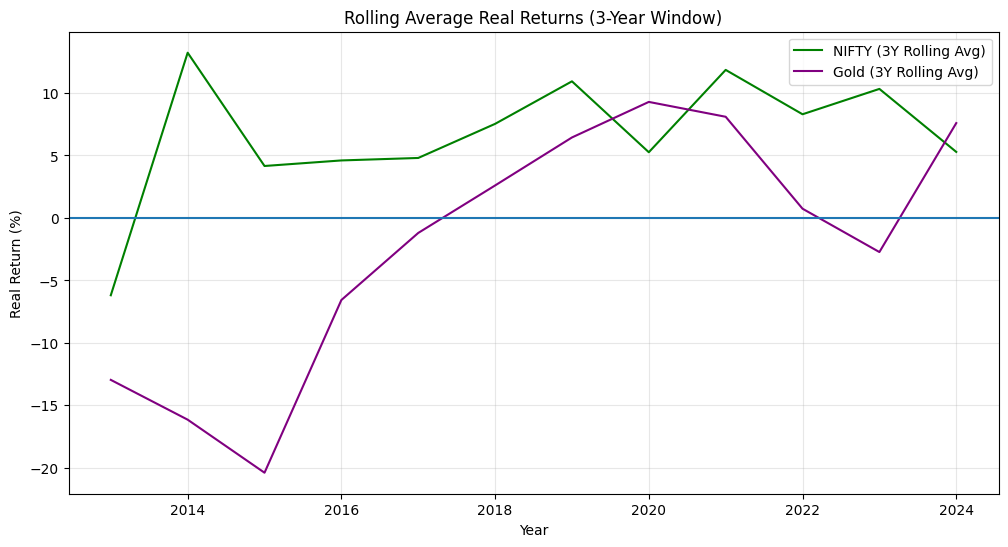

In [52]:
plt.figure(figsize=(12, 6))

plt.plot(
    master_df["Year"],
    master_df["Real_NIFTY_Return"].rolling(3).mean(),
    label="NIFTY (3Y Rolling Avg)",
    color="green"
)

plt.plot(
    master_df["Year"],
    master_df["Real_Gold_Return"].rolling(3).mean(),
    label="Gold (3Y Rolling Avg)",
    color="purple"
)

plt.axhline(0)
plt.title("Rolling Average Real Returns (3-Year Window)")
plt.xlabel("Year")
plt.ylabel("Real Return (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Key Inferences & Economic Interpretation

1. Nominal growth significantly overstates true wealth creation

While NIFTY exhibits strong long term nominal growth relative to gold, inflation materially erodes purchasing power in several years. Positive nominal returns frequently translate into muted or negative real returns, highlighting the inadequacy of nominal performance metrics for long-term investment evaluation.

2. Equities deliver higher average real returns at the cost of greater volatility

Inflation adjusted analysis confirms that Indian equities outperform gold in terms of average real returns over the long run. However, this outperformance is accompanied by substantially higher volatility and deeper drawdowns, reinforcing the classical risk–return trade-off rather than unconditional equity superiority.

3. Gold functions primarily as a purchasing-power stabilizer, not a growth asset

Gold demonstrates lower real return volatility and fewer extreme negative years compared to equities. Its role in the portfolio is better interpreted as capital preservation and downside protection rather than long term wealth maximization.

4. Inflation regimes materially alter asset performance dynamics

Asset returns in India are highly sensitive to inflation regimes. Equity real returns deteriorate markedly during high inflation periods, whereas gold displays relatively stronger and more stable real performance, supporting its empirical role as an inflation hedge.

5. Consistency and magnitude of returns diverge across assets

Although equities dominate gold in peak real return years, gold outperforms equities in consistency by exhibiting a lower frequency of negative real return outcomes. This divergence underscores the importance of evaluating both magnitude and reliability of returns.

6. Inflation adjusted analysis reveals periods of silent wealth erosion

Several periods of positive nominal asset performance coincide with negative real returns, implying silent erosion of purchasing power. This reinforces the necessity of inflation aware evaluation frameworks, particularly in emerging market contexts where inflation variability is higher.

7. Long term trends emerge only after smoothing short term volatility

Rolling average real returns indicate that short term fluctuations mask underlying performance trends. Equity returns stabilize over longer horizons, whereas gold maintains relatively stable but lower real returns, emphasizing horizon-dependent asset suitability.

8. Portfolio level implication: diversification is economically justified

The asymmetric behavior of equities and gold across inflation regimes supports diversification as an economically rational strategy. Combining growth-oriented equities with defensive gold exposure improves real return stability across macroeconomic conditions.

### Limitations

- Gold data is monthly, NIFTY is daily — year-end values are used for both to partially address this
- Real return is calculated as Nominal − CPI (Fisher approximation, not the exact formula)
- No dividends, transaction costs, or taxes are accounted for
- Past performance is not indicative of future results